<a href="https://colab.research.google.com/github/Muhammad-Awaix/-ML-Pyhton-Projects/blob/main/Bscics_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **EDA**

In [ ]:
import pandas as pd
df = pd.read_csv('/content/ecommerce_sales_analytics_5000.csv', parse_dates=['order_date'])
df.head(3)

,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue
0,10001,2022-01-01,1102,Beauty,South,7,373.65,0.28,Wallet,10,4.7,1883.20
1,10002,2022-01-02,1435,Clothing,South,7,47.74,0.09,Card,6,3.9,304.10
2,10003,2022-01-03,1860,Beauty,East,3,311.28,0.31,COD,6,2.5,644.35


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_id          5000 non-null   int64         
 1   order_date        5000 non-null   datetime64[ns]
 2   customer_id       5000 non-null   int64         
 3   product_category  5000 non-null   object        
 4   region            5000 non-null   object        
 5   quantity          5000 non-null   int64         
 6   unit_price        5000 non-null   float64       
 7   discount          5000 non-null   float64       
 8   payment_method    5000 non-null   object        
 9   delivery_days     5000 non-null   int64         
 10  customer_rating   5000 non-null   float64       
 11  revenue           5000 non-null   float64       
dtypes: datetime64[ns](1), float64(4), int64(4), object(3)
memory usage: 468.9+ KB


In [ ]:
df['payment_method'].unique()

array(['Wallet', 'Card', 'COD'], dtype=object)

In [ ]:
# map function is use on a series or single columns
df['payment_type'] = df['payment_method'].map(
    {'Wallet':'Digital',
     'Card':'Digital',
     'COD':'Cash'}
)
df.sample(2)

,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue,payment_type
1308,11309,2025-08-01,1606,Beauty,East,4,330.57,0.06,Card,10,1.7,1242.94,Digital
4083,14084,2033-03-07,1484,Electronics,North,3,490.57,0.27,Wallet,1,4.7,1074.35,Digital


In [ ]:
df['payment_type'].value_counts()

,count
payment_type,
Digital,3226
Cash,1774


In [ ]:
df['revenue'].describe()

,revenue
count,5000.000000
mean,1021.955148
std,825.584219
min,11.210000
25%,354.527500
50%,796.650000
75%,1515.690000
max,4119.330000


In [ ]:
#aaply is used on multipul columns and more flexibel then map
def revenue_cat(row):
    if row['revenue'] > 3500:
        return 'High'
    elif row['revenue'] >= 2000:
        return 'Medium'
    else:
        return "Low"
df['revenue_cat'] = df.apply(revenue_cat, axis=1)
df.sample(2)

,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue,payment_type,revenue_cat
3817,13818,2032-06-14,1659,Clothing,North,6,517.62,0.19,COD,11,3.5,2515.63,Cash,Medium
1904,11905,2027-03-20,1490,Clothing,South,5,15.77,0.14,Card,4,5.0,67.81,Digital,Low


In [ ]:
df['revenue_cat'].value_counts()

,count
revenue_cat,
Low,4291
Medium,683
High,26


In [ ]:
df.columns

Index(['order_id', 'order_date', 'customer_id', 'product_category', 'region',
       'quantity', 'unit_price', 'discount', 'payment_method', 'delivery_days',
       'customer_rating', 'revenue', 'payment_type', 'revenue_cat'],
      dtype='object')

In [ ]:
df.sample(2)

,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue,payment_type,revenue_cat
1145,11146,2025-02-19,1182,Beauty,North,2,315.88,0.31,COD,9,4.9,435.91,Cash,Low
3847,13848,2032-07-14,1562,Clothing,North,3,485.09,0.21,Card,6,2.4,1149.66,Digital,Low


In [ ]:
#pipe is used if we want to do perform some operations in sequence
def add_profit(data):
    data['profit'] = df['revenue']*0.20
    return data
def net_revinue(data):
    data['net_revinue'] = data['revenue'] - data['profit']
    return data

df = (
    df.pipe(add_profit)
    .pipe(net_revinue)
)

In [ ]:
df.sample(3)

,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue,payment_type,revenue_cat,profit,net_revinue
3496,13497,2031-07-29,1844,Home,North,2,470.52,0.26,Card,8,4.0,696.37,Digital,Low,139.274,557.096
105,10106,2022-04-16,1269,Beauty,West,6,572.68,0.25,Card,5,4.2,2577.06,Digital,Medium,515.412,2061.648
3931,13932,2032-10-06,1398,Electronics,North,7,206.72,0.02,Card,10,2.0,1418.10,Digital,Low,283.620,1134.480


In [ ]:
# First we select the columns, then we ask for the description
df[['quantity', 'unit_price', 'discount', 'revenue', 'profit']].describe()

,quantity,unit_price,discount,revenue,profit
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,4.044800,308.418774,0.179984,1021.955148,204.391030
std,2.020398,169.259369,0.101404,825.584219,165.116844
min,1.000000,15.150000,0.000000,11.210000,2.242000
25%,2.000000,161.895000,0.090000,354.527500,70.905500
50%,4.000000,309.890000,0.180000,796.650000,159.330000
75%,6.000000,455.557500,0.270000,1515.690000,303.138000
max,7.000000,599.960000,0.350000,4119.330000,823.866000


In [ ]:
df['revenue'].quantile([0.25, 0.5, 0.75])

,revenue
0.25,354.5275
0.50,796.6500
0.75,1515.6900


In [ ]:
df['revenue'].median(), df['revenue'].mean()

(796.65, np.float64(1021.955148))

In [ ]:
df['revenue'].skew()
# this is right skewd if +ve right if -ve left if 0 not skewd

np.float64(1.0017064603000962)

In [ ]:
df.index

RangeIndex(start=0, stop=5000, step=1)

In [ ]:
df = df.set_index('order_date')
df.index

DatetimeIndex(['2022-01-01', '2022-01-02', '2022-01-03', '2022-01-04',
               '2022-01-05', '2022-01-06', '2022-01-07', '2022-01-08',
               '2022-01-09', '2022-01-10',
               ...
               '2035-08-31', '2035-09-01', '2035-09-02', '2035-09-03',
               '2035-09-04', '2035-09-05', '2035-09-06', '2035-09-07',
               '2035-09-08', '2035-09-09'],
              dtype='datetime64[ns]', name='order_date', length=5000, freq=None)

In [ ]:
df.head()

,order_id,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue,payment_type,revenue_cat,profit,net_revinue
order_date,,,,,,,,,,,,,,,
2022-01-01,10001,1102,Beauty,South,7,373.65,0.28,Wallet,10,4.7,1883.20,Digital,Low,376.640,1506.560
2022-01-02,10002,1435,Clothing,South,7,47.74,0.09,Card,6,3.9,304.10,Digital,Low,60.820,243.280
2022-01-03,10003,1860,Beauty,East,3,311.28,0.31,COD,6,2.5,644.35,Cash,Low,128.870,515.480
2022-01-04,10004,1270,Electronics,West,5,524.47,0.02,Wallet,6,1.6,2569.90,Digital,Medium,513.980,2055.920
2022-01-05,10005,1106,Clothing,West,5,139.87,0.33,Wallet,4,4.9,468.56,Digital,Low,93.712,374.848


In [ ]:
monthly_rev = df['revenue'].resample('ME').sum()
monthly_rev

,revenue
order_date,
2022-01-31,35624.89
2022-02-28,29908.89
2022-03-31,30309.28
2022-04-30,30781.96
2022-05-31,41629.24
...,...
2035-05-31,33393.87
2035-06-30,25205.26
2035-07-31,23944.48


In [ ]:
monthly_rev.pct_change()

,revenue
order_date,
2022-01-31,NaN
2022-02-28,-0.160450
2022-03-31,0.013387
2022-04-30,0.015595
2022-05-31,0.352391
...,...
2035-05-31,0.201727
2035-06-30,-0.245213
2035-07-31,-0.050021


In [ ]:
monthly_rev.index.is_monotonic_increasing

True

## Removing the outliers
- IQR
- Zscore

In [ ]:
import pandas as pd
df = pd.read_csv('/content/ecommerce_sales_analytics_5000.csv', parse_dates=['order_date'])
df.head(3)

,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue
0,10001,2022-01-01,1102,Beauty,South,7,373.65,0.28,Wallet,10,4.7,1883.20
1,10002,2022-01-02,1435,Clothing,South,7,47.74,0.09,Card,6,3.9,304.10
2,10003,2022-01-03,1860,Beauty,East,3,311.28,0.31,COD,6,2.5,644.35


In [ ]:
df.columns

Index(['order_id', 'order_date', 'customer_id', 'product_category', 'region',
       'quantity', 'unit_price', 'discount', 'payment_method', 'delivery_days',
       'customer_rating', 'revenue'],
      dtype='object')

In [ ]:
df['revenue'].describe()

,revenue
count,5000.000000
mean,1021.955148
std,825.584219
min,11.210000
25%,354.527500
50%,796.650000
75%,1515.690000
max,4119.330000


In [ ]:
Q1 = df['revenue'].quantile(0.25)
Q3 = df['revenue'].quantile(0.75)
IQR = Q3-Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_iqr = df[(df['revenue'] < lower_bound) | (df['revenue'] > upper_bound)]
outliers_iqr.shape

(67, 12)

In [ ]:
df = df[(df['revenue'] >= lower_bound) & (df['revenue'] <= upper_bound)]
df.shape

(4933, 12)

In [ ]:
from scipy.stats import zscore
df = pd.read_csv('/content/ecommerce_sales_analytics_5000.csv', parse_dates=['order_date'])
df['revenue_z'] = zscore(df['revenue'])
outliers_z = df[df['revenue_z'].abs()>3]
outliers_z.shape

(26, 13)

In [ ]:
df = df[df['revenue_z'].abs() <= 3]
df.shape

(4974, 13)

## Correlation and Covariance
*Measure the relationshiop b/w numeric variables*
- +ve
- -ve

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4974 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_id          4974 non-null   int64         
 1   order_date        4974 non-null   datetime64[ns]
 2   customer_id       4974 non-null   int64         
 3   product_category  4974 non-null   object        
 4   region            4974 non-null   object        
 5   quantity          4974 non-null   int64         
 6   unit_price        4974 non-null   float64       
 7   discount          4974 non-null   float64       
 8   payment_method    4974 non-null   object        
 9   delivery_days     4974 non-null   int64         
 10  customer_rating   4974 non-null   float64       
 11  revenue           4974 non-null   float64       
 12  revenue_z         4974 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int64(4), object(3)
memory usage: 544.0+ KB


In [ ]:
numeric_cols = df[['quantity','unit_price','discount','revenue']]
print(numeric_cols.cov())
print()
print(numeric_cols.corr())

               quantity    unit_price  discount        revenue
quantity       4.057453     -3.554419  0.001031    1002.959663
unit_price    -3.554419  28434.609259  0.395646   91454.701455
discount       0.001031      0.395646  0.010247      -9.922703
revenue     1002.959663  91454.701455 -9.922703  645471.483818

            quantity  unit_price  discount   revenue
quantity    1.000000   -0.010464  0.005057  0.619752
unit_price -0.010464    1.000000  0.023178  0.675062
discount    0.005057    0.023178  1.000000 -0.122006
revenue     0.619752    0.675062 -0.122006  1.000000


# Data Visualization

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
df = pd.read_csv('/content/global_ecommerce_sales.csv')
df.head(2)

,Order_ID,Order_Date,Customer_Name,Customer_Segment,Country,Region,Product_Category,Product_Name,Quantity,Unit_Price,Discount_Percent,Total_Sales,Shipping_Cost,Profit,Payment_Method
0,ORD-11121,2023-01-02,Karen Suzuki,Corporate,United States,North America,Technology,Wireless Bluetooth Headphones,3,99.43,0,298.29,9.31,124.92,Cash on Delivery
1,ORD-11244,2023-01-02,John Johansson,Corporate,Spain,Europe,Technology,Mechanical Gaming Keyboard,4,97.93,20,313.38,14.31,83.62,Cash on Delivery


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          2000 non-null   object 
 1   Order_Date        2000 non-null   object 
 2   Customer_Name     2000 non-null   object 
 3   Customer_Segment  2000 non-null   object 
 4   Country           2000 non-null   object 
 5   Region            2000 non-null   object 
 6   Product_Category  2000 non-null   object 
 7   Product_Name      2000 non-null   object 
 8   Quantity          2000 non-null   int64  
 9   Unit_Price        2000 non-null   float64
 10  Discount_Percent  2000 non-null   int64  
 11  Total_Sales       2000 non-null   float64
 12  Shipping_Cost     2000 non-null   float64
 13  Profit            2000 non-null   float64
 14  Payment_Method    2000 non-null   object 
dtypes: float64(4), int64(2), object(9)
memory usage: 234.5+ KB


In [4]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

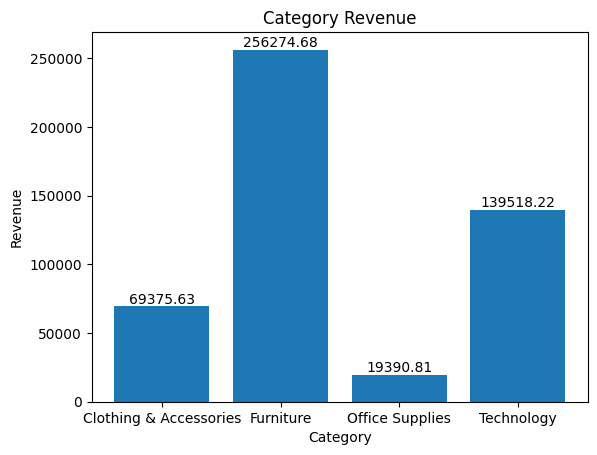

In [13]:
cat_revenue = df.groupby('Product_Category')['Total_Sales'].sum()
fig, ax = plt.subplots()
ax.bar(cat_revenue.index, cat_revenue.values)
ax.set_title('Category Revenue')
ax.set_xlabel('Category')
ax.set_ylabel('Revenue')

# Add data labels using ax.bar_label()
ax.bar_label(ax.containers[0], fmt='%.2f') # ax.containers[0] refers to the bars generated by ax.bar()
plt.show()


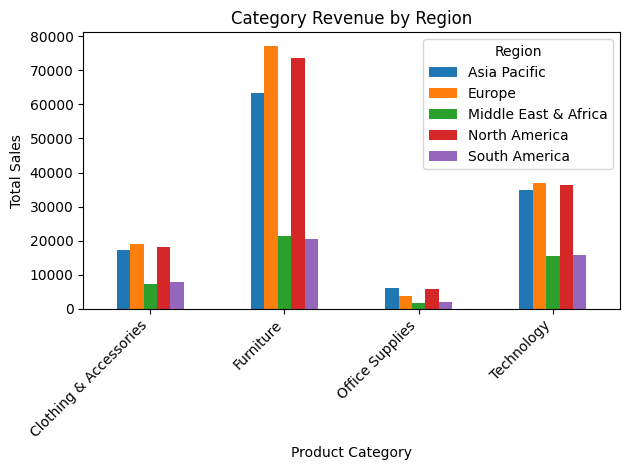

In [16]:
grouped = df.groupby(['Product_Category', 'Region'])['Total_Sales'].sum().unstack()
fig, ax = plt.subplots()
grouped.plot(kind='bar', ax=ax)
ax.set_title('Category Revenue by Region') # Changed title for clarity
ax.set_xlabel('Product Category') # Changed label for clarity
ax.set_ylabel('Total Sales') # Changed label for clarity
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()